# Plot the current sensor montage

This notebook compares the EEG sensors that the current Eelbrain pipeline actually loads with the complete 61-position montage configured in `pipeline.py`.

In [1]:
%matplotlib inline

from pathlib import Path

from eelbrain import load_pipeline, plot


def find_project_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / 'analysis/trf_pipeline/pipeline.py').is_file():
            return candidate
    raise FileNotFoundError('Could not find analysis/trf_pipeline/pipeline.py')


PROJECT_ROOT = find_project_root()
PIPELINE_DIR = PROJECT_ROOT / 'analysis/trf_pipeline'
SUBJECT = '01'

e = load_pipeline(PIPELINE_DIR)

INFO    :  *** AliceComprehension initialized with root /Users/yanyuwoo/Data/bids on 2026-08-04 17:50:25 ***
INFO    :  Using eelbrain 0.43.0a1, mne 1.11.0.


## Sensors currently used by the pipeline

Load one subject through the formal pipeline. This view should contain only the EEG sensors that enter the current analysis.

In [2]:
epochs = e.load_epochs(
    subject=SUBJECT,
    epoch='story-segments',
    raw='0.5-20',
)
eeg = epochs[0, 'eeg']

configured_names = [str(index) for index in range(1, 62)]
loaded_names = list(eeg.sensor.names)
missing_names = [name for name in configured_names if name not in loaded_names]
unexpected_names = [name for name in loaded_names if name not in configured_names]

print(f'Subject: {SUBJECT}')
print(f'Loaded EEG sensors: {len(loaded_names)}')
print(f'Missing from the 61-position montage: {missing_names}')
print(f'Unexpected EEG sensor names: {unexpected_names}')
print(f'VEOG included: {"VEOG" in loaded_names}')
print(f'AUD included: {"AUD" in loaded_names}')

assert missing_names == ['29']
assert not unexpected_names
assert 'VEOG' not in loaded_names
assert 'AUD' not in loaded_names

INFO    :  Raw 0.5-20: filtering for /Users/yanyuwoo/Data/bids/sub-01/eeg/sub-01_task-alice_eeg.vhdr...
Subject: 01
Loaded EEG sensors: 60
Missing from the 61-position montage: ['29']
Unexpected EEG sensor names: []
VEOG included: False
AUD included: False


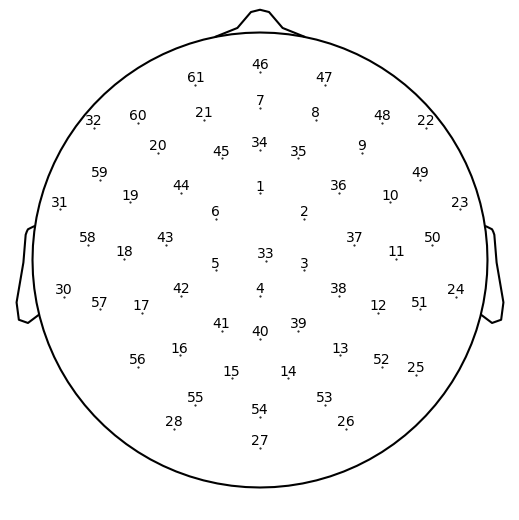

In [3]:
current_sensor_plot = plot.SensorMap(
    eeg,
    labels='name',
    head_radius=True,
)

## Complete montage configured in `pipeline.py`

The `RawSource` montage contains all 61 electrode positions, including channel 29, which is absent from the stored EEG because it was the implicit acquisition reference.

Configured montage positions: 61
Channel 29 configured: True


/var/folders/j8/hc9f3z3931ld2qv6m5zzg0t80000gn/T/ipykernel_24543/553178990.py:5: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  montage.plot(


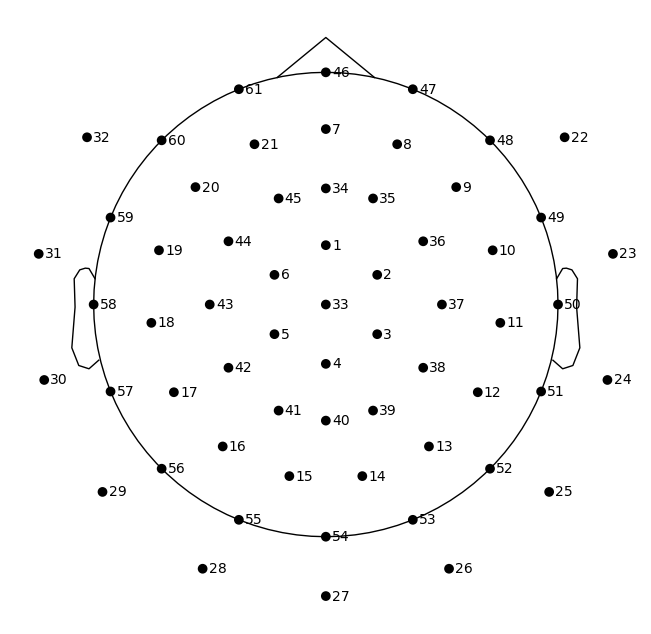

/var/folders/j8/hc9f3z3931ld2qv6m5zzg0t80000gn/T/ipykernel_24543/553178990.py:10: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  montage.plot(


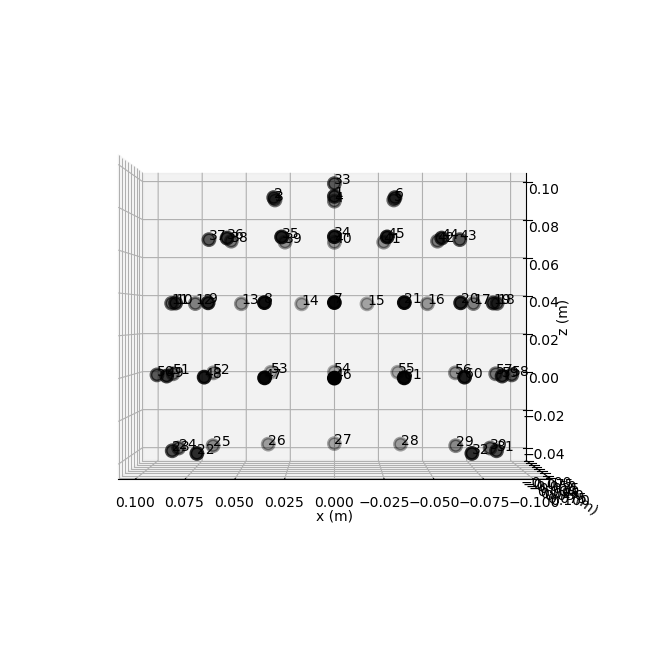

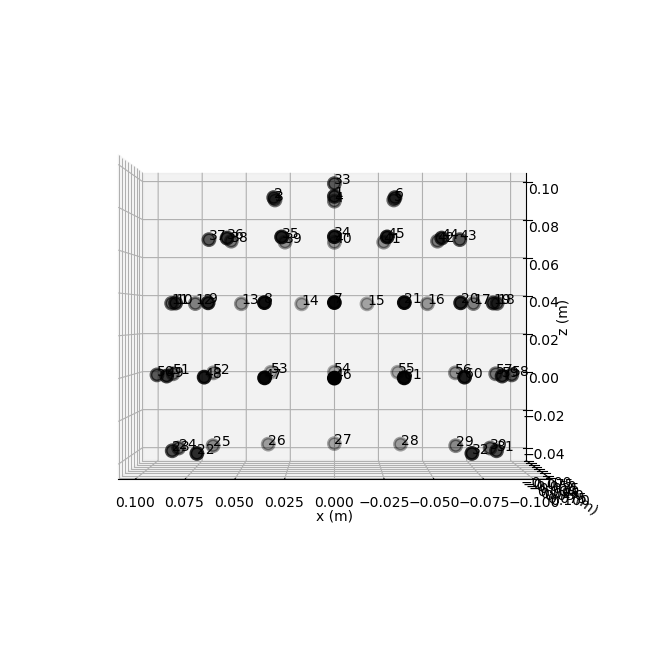

In [ ]:
montage = e.raw['raw'].montage
print(f'Configured montage positions: {len(montage.ch_names)}')
print(f'Channel 29 configured: {"29" in montage.ch_names}')

montage.plot(
    kind='topomap',
    show_names=True,
)

# montage.plot(
#     kind="3d",  
#     show_names=True,
# )

## Expected interpretation

- **Current pipeline data:** 60 EEG sensors (`1-28`, `30-61`), with no `VEOG` or `AUD`.
- **Configured montage:** 61 electrode positions (`1-61`), including the missing reference channel `29`.
- After channel `29` is reconstructed during re-referencing, the pipeline should contain 61 EEG sensors while still excluding `VEOG` and `AUD`.